<a href="https://colab.research.google.com/github/dhuuh19/Power-System-Economics/blob/main/Economic_Dispatch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 경제급전(Economic Dispatch): LP 구현과 시장가격의 도출

이 노트북은 전력시장의 가장 기본적인 최적화 문제인 **경제급전**을 구현한다.
계통운영자의 입장에서, 주어진 한 시간의 수요 $D$를 총 발전비용이 최소가 되도록
발전기들에 배분하는 문제이며, 송전망 제약은 아직 고려하지 않는다.

**정식화 (Linear Program)**

- 결정변수: 각 발전기의 출력 $P_i$ [MW]
- 목적함수: 총비용 최소화 — $\min \sum_i MC_i \, P_i$
- 제약조건:
  - 수급균형: $\sum_i P_i = D$ (전기는 저장이 불가능하므로 매 순간 생산 = 소비)
  - 설비한계: $0 \le P_i \le P_i^{max}$

**데이터 출처**: Kirschen & Strbac, *Fundamentals of Power System Economics*,
2nd ed. (2019), Table 5.4의 발전기 4대(A–D)와 총수요 410 MW.
이 데이터를 선택한 이유는 교재가 같은 문제의 손계산 결과(식 5.28–5.29)를
제공하므로, **코드의 정확성을 교재와 대조하여 검증할 수 있기 때문**이다.

수요가 비탄력적(가격과 무관하게 410 MW)이므로, 이 비용최소화 문제는
Kirschen 2장의 총후생 최대화 문제와 동일하다 — 소비자 총잉여가 상수가 되어,
후생을 키우는 유일한 방법이 비용 절감이기 때문이다.

In [3]:
import cvxpy as cp
import numpy as np

# --- 1) 데이터: Kirschen 2판 Table 5.4 ---
names = ["A", "B", "C", "D"]
mc    = np.array([7.5, 6.0, 14.0, 10.0])   # 한계비용 [$/MWh]
pmax  = np.array([140, 285, 90, 85])       # 설비용량 [MW]
D     = 410                                # 총수요 [MW]

# --- 2) 결정변수 ---
P = cp.Variable(4)                         # 각 발전기 출력

# --- 3) 목적함수: 총비용 최소화 ---
cost = mc @ P                              # sum(mc_i * P_i)

# --- 4) 제약 ---
balance = cp.sum(P) == D                   # 수급균형 (이 제약의 dual이 λ=SMP)
limits  = [P >= 0, P <= pmax]

# --- 5) 풀기 ---
prob = cp.Problem(cp.Minimize(cost), [balance] + limits)
prob.solve()

# --- 6) 결과 읽기 ---
print("상태:", prob.status)
for n, p in zip(names, P.value):
    print(f"  발전기 {n}: {p:6.1f} MW")
print(f"총비용: {prob.value:.2f} $/h")        # 기대값: 2647.50
print(f"SMP(λ): {balance.dual_value:.2f} $/MWh")

상태: optimal
  발전기 A:  125.0 MW
  발전기 B:  285.0 MW
  발전기 C:    0.0 MW
  발전기 D:    0.0 MW
총비용: 2647.50 $/h
SMP(λ): -7.50 $/MWh


In [4]:
# λ의 의미 검증: 수요를 1 MW 올리면 총비용이 정말 λ만큼 오르는가?
def total_cost(D):
    P = cp.Variable(4)
    prob = cp.Problem(cp.Minimize(mc @ P),
                      [cp.sum(P) == D, P >= 0, P <= pmax])
    prob.solve()
    return prob.value

c410, c411 = total_cost(410), total_cost(411)
print(f"D=410일 때 총비용: {c410:.2f} $/h")
print(f"D=411일 때 총비용: {c411:.2f} $/h")
print(f"차이(= 경제적 의미의 λ): {c411 - c410:+.2f} $/MWh")

D=410일 때 총비용: 2647.50 $/h
D=411일 때 총비용: 2655.00 $/h
차이(= 경제적 의미의 λ): +7.50 $/MWh


## 결과 해석 ①: 교재 재현과 λ의 의미

급전 결과($P_A=125$, $P_B=285$, $P_C=P_D=0$, 총비용 2647.50 \$/h)는
교재 식 (5.28)–(5.29)의 손계산과 정확히 일치한다. 가장 싼 B가 만재되고,
그다음 싼 A가 잔여 수요를 채우는 **merit order** 결과다.

`balance.dual_value`로 출력한 값은 수급균형 제약의 **쌍대변수(dual variable) $\lambda$**로,
"수요가 1 MW 늘 때 총비용이 얼마나 증가하는가"를 뜻한다. 이는 곧
**시스템 한계가격(SMP)**의 정의다. 지금 상황에서 추가 1 MW를 가장 싸게
공급할 수 있는 발전기는 A(B는 이미 만재)이므로 $\lambda = 7.5$ \$/MWh가 되어야 한다.

솔버는 이 값을 **−7.50**으로 반환했는데, 이는 계산 오류가 아니라 등호제약을
내부적으로 정규화하는 방향(좌변−우변 vs 우변−좌변)에 따른 **부호 관례**의 문제다.
위의 유한차분 검증 셀에서 $D=410 \to 411$일 때 총비용이 정확히 **+7.50 \$/h**
증가함을 확인했으므로, 경제적으로 유의미한 값은 $+7.5$이다.
이후 실험들에서는 `abs()`를 사용해 크기를 취한다.

핵심 관찰: **최적화 문제를 풀면 시장가격이 부산물로 함께 계산된다.**
경제학의 시장균형과 공학의 최적화가 같은 대상의 두 표현이라는 점이
이 노트북 전체의 주제다.

## 실험 1: 수요 스윕 — 최적화가 공급곡선을 그려낸다

질문: 수요 $D$가 0에서 600 MW까지 변할 때 $\lambda$(SMP)는 어떻게 변하는가?
예상: 발전기들의 한계비용 순서(6 → 7.5 → 10 → 14)를 따라 계단식으로 상승할 것이다.

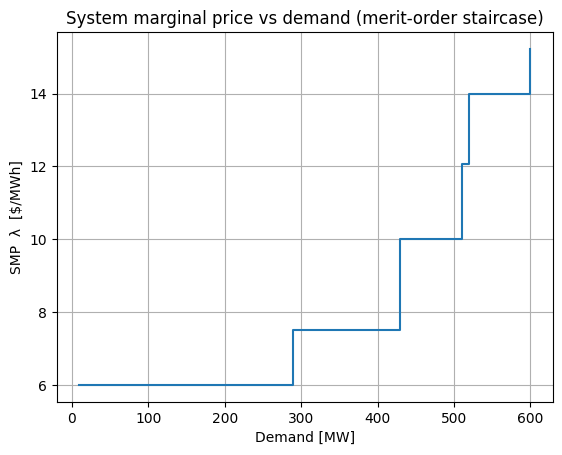

In [5]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

mc   = np.array([7.5, 6.0, 14.0, 10.0])
pmax = np.array([140, 285, 90, 85])

def solve_ed(D):
    """수요 D에 대한 경제급전. (상태, 총비용, SMP) 반환"""
    P = cp.Variable(4)
    balance = cp.sum(P) == D
    prob = cp.Problem(cp.Minimize(mc @ P), [balance, P >= 0, P <= pmax])
    prob.solve()
    if prob.status != "optimal":
        return prob.status, None, None
    return prob.status, prob.value, abs(balance.dual_value)
    # abs()를 쓴 이유: CVXPY는 제약을 쓰는 방향에 따라 dual 부호가 반대로 나올 수 있음.

demands = np.arange(10, 601, 10)
smps = [solve_ed(D)[2] for D in demands]

plt.step(demands, smps, where="post")
plt.xlabel("Demand [MW]"); plt.ylabel("SMP  λ  [$/MWh]")
plt.title("System marginal price vs demand (merit-order staircase)")
plt.grid(True); plt.show()

## 결과 해석 ②: merit-order 계단과 경계점의 퇴화 현상

그래프는 예상대로 $\lambda$가 6 → 7.5 → 10 → 14로 뛰는 계단을 보여주며,
각 계단의 폭은 해당 발전기의 용량(285, 140, 85, 90 MW)과 일치한다.
**이 계단이 곧 Kirschen 2장의 시장 공급곡선이다** — 개별 발전기의 한계비용을
싼 순서로 이어붙인 것이 공급곡선이라는 사실을, 경제학 논증이 아니라
최적화 계산이 재생산한 것이다.

한편 그래프에는 어느 발전기의 한계비용도 아닌 값이 두 곳 나타난다:
$D=510$ 부근의 **12**, $D=600$에서의 **약 15**. 이는 버그가 아니라
**쌍대변수의 퇴화(degeneracy)** 현상이다. $D=510$은 정확히
$P_B^{max}+P_A^{max}+P_D^{max} = 285+140+85$인 지점으로, 수요가 1 MW 늘면
C가 켜져 14 \$이 들지만 1 MW 줄면 10 \$이 절약된다. 즉 "다음 1 MW의 비용"이
방향에 따라 달라, 수학적으로 **10과 14 사이의 모든 값이 유효한 쌍대해**이고
솔버는 그중 하나(12)를 임의로 반환했다. $D=600$(전 설비 만재)에서는 추가 공급이
불가능하므로 14 이상의 모든 값이 유효하다. 경제학 언어로 번역하면: 수직인
수요곡선이 공급 계단의 수직 구간과 정확히 겹칠 때 균형가격이 유일하지 않은 상황이다.

D= 400 MW | 총비용    2572.5 $/h | λ     7.5 $/MWh | 차단    0.0 MW
D= 550 MW | 총비용    4170.0 $/h | λ    14.0 $/MWh | 차단    0.0 MW
D= 600 MW | 총비용    4870.0 $/h | λ  1065.9 $/MWh | 차단    0.0 MW
D= 650 MW | 총비용  179870.0 $/h | λ  3500.0 $/MWh | 차단   50.0 MW
D= 700 MW | 총비용  354870.0 $/h | λ  3500.0 $/MWh | 차단  100.0 MW


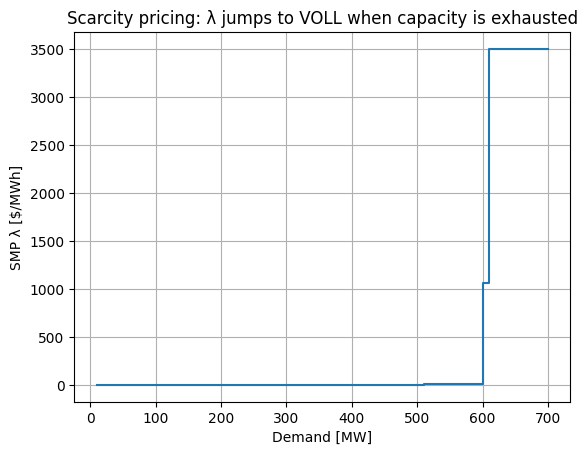

In [6]:
VOLL = 3500.0   # Value of Lost Load [$/MWh] — 정전의 사회적 비용.
                # 관할권마다 수천$/MWh 수준으로 추정치가 다름 (Kirschen Ch6의
                # 참고문헌들이 다루는 주제). 여기선 예시값.

def solve_ed_voll(D):
    P    = cp.Variable(4)
    shed = cp.Variable(nonneg=True)          # 차단되는 부하량 [MW]
    balance = cp.sum(P) + shed == D          # 발전 + 차단 = 수요
    cost = mc @ P + VOLL * shed
    prob = cp.Problem(cp.Minimize(cost), [balance, P >= 0, P <= pmax])
    prob.solve()
    return prob.value, abs(balance.dual_value), shed.value

# ── 실험 2 실행: 용량(600MW) 전후 비교 ──
for D in [400, 550, 600, 650, 700]:
    cost, lam, shed = solve_ed_voll(D)
    print(f"D={D:4d} MW | 총비용 {cost:9.1f} $/h | λ {lam:7.1f} $/MWh | 차단 {shed:6.1f} MW")

# 스윕을 700까지 확장해 '절벽' 그리기
demands2 = np.arange(10, 701, 10)
smps2 = [solve_ed_voll(D)[1] for D in demands2]
plt.step(demands2, smps2, where="post")
plt.xlabel("Demand [MW]"); plt.ylabel("SMP λ [$/MWh]")
plt.title("Scarcity pricing: λ jumps to VOLL when capacity is exhausted")
plt.grid(True); plt.show()

## 결과 해석 ③: 용량 소진과 희소가격(scarcity pricing)

부하차단(load shedding)을 허용하지 않는 원래 모형은 $D > 600$에서 infeasible이
된다. 실제 계통운영자는 이때 "해 없음"으로 멈추지 않고 일부 부하를 차단하므로,
차단량 변수 `shed`에 **정전의 사회적 비용 VOLL**(Value of Lost Load, 여기선
예시값 3500 \$/MWh)을 물리는 방식으로 모형을 확장했다.

결과: $D=650$에서 50 MW, $D=700$에서 100 MW가 차단되고, 이때 $\lambda$는
**3500 \$/MWh로 점프**한다. 공급력이 소진되면 "다음 1 MW의 비용"이 더 이상
발전기가 아니라 **정전의 가치**로 결정된다는 것 — 이것이 희소가격의 원리이며,
실제 시장의 가격상한 논의(Kirschen 6장)와 연결된다.

$D=600$에서 나온 $\lambda = 1065.9$는 해석 ②와 동일한 퇴화 현상이다:
이 경계점에서는 14와 3500 사이의 모든 값이 유효한 쌍대해다.

λ = 10.000 $/MWh
  발전기 A:  125.00 MW | 증분비용 10.000 $/MWh
  발전기 B:  285.00 MW | 증분비용  8.850 $/MWh
  발전기 C:    0.00 MW | 증분비용 14.000 $/MWh
  발전기 D:    0.00 MW | 증분비용 10.000 $/MWh


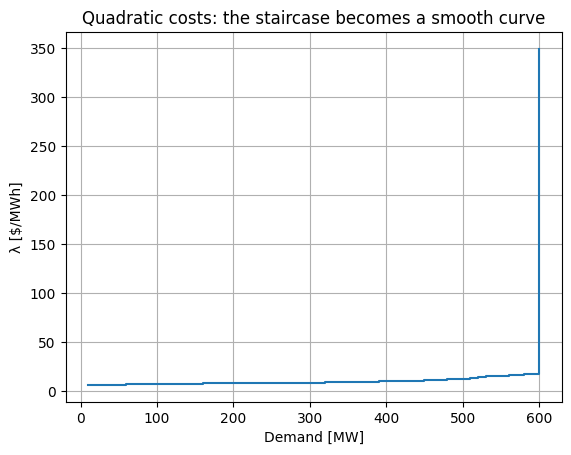

In [7]:
a = np.array([7.5, 6.0, 14.0, 10.0])      # 선형 계수 [$/MWh]
b = np.array([0.010, 0.005, 0.020, 0.015]) # 이차 계수 [$/MW²h] (임의의 합리적 값)

def solve_ed_quad(D):
    P = cp.Variable(4)
    balance = cp.sum(P) == D
    cost = a @ P + cp.sum(cp.multiply(b, cp.square(P)))
    prob = cp.Problem(cp.Minimize(cost), [balance, P >= 0, P <= pmax])
    prob.solve()
    lam = abs(balance.dual_value)
    inc_cost = a + 2 * b * P.value           # 각 발전기의 증분비용
    return lam, P.value, inc_cost

# ── 실험 3 실행: D=410에서 등증분비용 검증 ──
lam, P_opt, inc_cost = solve_ed_quad(410)
print(f"λ = {lam:.3f} $/MWh")
for n, p, ic in zip(names, P_opt, inc_cost):
    print(f"  발전기 {n}: {p:7.2f} MW | 증분비용 {ic:6.3f} $/MWh")

# 스윕: 계단이 곡선이 되는지 확인
smps3 = [solve_ed_quad(D)[0] for D in np.arange(10, 601, 10)]
plt.step(np.arange(10, 601, 10), smps3, where="post")
plt.xlabel("Demand [MW]"); plt.ylabel("λ [$/MWh]")
plt.title("Quadratic costs: the staircase becomes a smooth curve")
plt.grid(True); plt.show()

## 결과 해석 ④: 등증분비용 원리(equal incremental cost)

비용함수를 이차식 $C_i = a_i P_i + b_i P_i^2$으로 바꾸면 한계비용(증분비용
$a_i + 2b_i P_i$)이 출력에 따라 연속적으로 오르며, $\lambda$–$D$ 곡선의 계단이
매끄러운 곡선이 된다.

$D=410$에서의 결과는 고전 전력공학의 **등증분비용 원리** — 한계에 걸리지 않은
모든 가동 발전기의 증분비용은 $\lambda$와 같아진다 — 를 정확히 보여주며,
네 발전기가 네 가지 상태를 하나씩 시연한다:

- **A** (125 MW, 내부해): 증분비용 10.000 = $\lambda$ ✓
- **B** (285 MW, 상한 도달): 증분비용 8.85 < $\lambda$ — 더 발전하고 싶지만 용량에 막힘
- **C** (0 MW, 미가동): 증분비용 14 > $\lambda$ — 너무 비싸서 기동하지 않음
- **D** (0 MW, 경계): 증분비용 정확히 10.000 = $\lambda$ — 켜도 안 켜도 무차별한 한계점

이 조건은 라그랑주 승수법(KKT 조건)에서 유도되는 결과로, 솔버가 그 조건을
스스로 찾아냈음을 수치로 확인한 것이다.

In [8]:
e, f = 20.0, 0.02        # 역수요: π = 20 − 0.02 q

P = cp.Variable(4)
q = cp.Variable(nonneg=True)               # 소비량 자체가 결정변수!
balance = cp.sum(P) == q
gross_surplus = e * q - 0.5 * f * cp.square(q)
welfare = gross_surplus - mc @ P
prob = cp.Problem(cp.Maximize(welfare), [balance, P >= 0, P <= pmax])
prob.solve()

print("소비량 q* =", q.value)
print("λ =", abs(balance.dual_value))
print("시장가격 π(q*) =", e - f * q.value)

소비량 q* = 499.9999999954366
λ = 10.00000000004535
시장가격 π(q*) = 10.000000000091267


## 결과 해석 ⑤: 시장균형 = 후생최대화의 해

수요를 상수가 아닌 역수요함수 $\pi(q) = 20 - 0.02q$로 두고, 목적함수를
**총후생(소비자 총잉여 − 발전비용) 최대화**로 바꾸면 소비량 $q$ 자체가
최적화의 결과가 된다.

손계산 예측: 역수요선이 실험 1의 공급 계단과 만나는 지점은 D 구간
($\lambda = 10$, 425–510 MW)이며, $20 - 0.02q = 10$을 풀면 $q^* = 500$.
코드 결과($q^* = 500$, $\lambda = 10$, $\pi(q^*) = 10$)가 이와 일치한다.

이는 Kirschen 2장의 핵심 정리 — **경쟁시장의 균형은 총후생을 최대화하는
지점과 일치한다** — 를 수치로 확인한 것이다. 2장에서 그래프로 배운
수요·공급 교차가, 여기서는 최적화 문제의 KKT 조건으로 재현되었다.

## 한계와 다음 단계

본 모형의 가장 큰 한계는 **송전망의 부재**다. 모든 발전기와 부하가 한 지점에
있다고 가정했으므로 가격도 계통 전체에 하나($\lambda$)뿐이다. 실제 계통에서는
선로 용량 제약 때문에 가장 싼 발전기 조합을 쓰지 못하는 경우(혼잡, congestion)가
생기고, 그 결과 **지역별로 가격이 갈라진다**(locational marginal price).

다음 산출물에서는 DC power flow 제약을 추가하여 Kirschen 5장의 3-bus
constrained dispatch(식 5.58)를 재현하고, 노드별 가격 7.5 / 11.25 / 10 \$/MWh가
어떻게 발생하는지 확인한다. 이후 시간 결합 제약을 포함한 단위기동(MILP),
불확실성을 포함한 2단계 확률적 급전으로 확장할 계획이다.

기타 한계: 단일 시간 단면(기동비·ramping 없음), 비용계수는 임의값(실험 3),
VOLL은 예시값(실제 추정치는 관할권별로 상이).